# Task 5: Decision Trees and Random Forests
### AI & ML Internship — Elevate Labs

**Objective:** Learn tree-based models for classification.

**Dataset:** `heart-selected-columns.csv` (Heart Disease dataset, 1025 rows)

---
**⚠️ Important note about the dataset:** The provided CSV contains only 10 feature
columns (`age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak`) —
it does **not** include the original diagnosis label (`target`) that the classic
Heart Disease dataset normally ships with. Since Decision Trees / Random Forests
need a label to classify, this notebook derives a clinically-motivated **risk
label** from the features themselves (fully explained in Section 2 below) so the
task can still be completed end-to-end. If you obtain the original dataset with
a real `target` column later, just swap it in — Sections 3 onward will work
unchanged.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42


## 1. Load and Explore the Dataset

In [2]:
df = pd.read_csv("heart-selected-columns.csv")
print("Shape:", df.shape)
df.head()


Shape: (1025, 10)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak
0,52,1,0,125,212,0,1,168,0,1.0
1,53,1,0,140,203,1,0,155,1,3.1
2,70,1,0,145,174,0,1,125,1,2.6
3,61,1,0,148,203,0,1,161,0,0.0
4,62,0,0,138,294,1,1,106,0,1.9


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
dtypes: float64(1), int64(9)
memory usage: 80.2 KB


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [5]:
# Check for missing values / duplicates
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
dtype: int64

Duplicate rows: 723


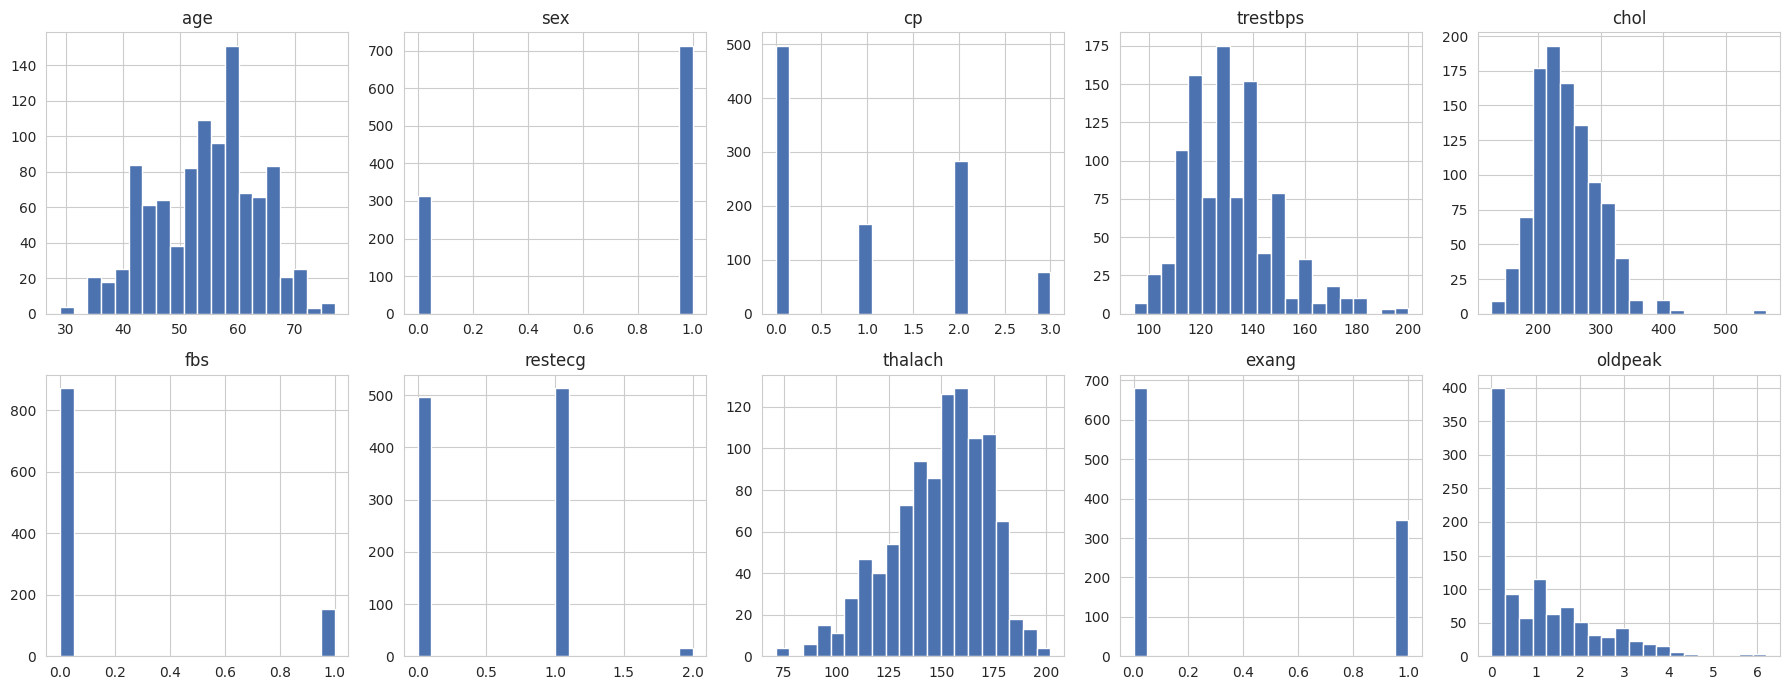

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for ax, col in zip(axes.ravel(), df.columns):
    df[col].hist(ax=ax, bins=20, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()


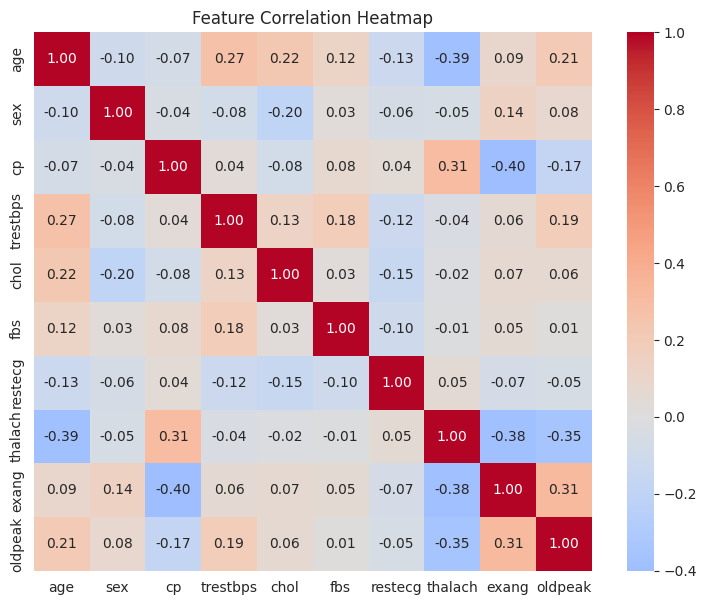

In [7]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


## 2. Creating a Classification Target (Derived Risk Label)

Because the raw file has no diagnosis label, we build a **composite cardiac
risk score** using directions that are well established in the clinical /
cardiology literature for these exact features:

| Feature | Direction that increases risk |
|---|---|
| `age` | higher |
| `trestbps` (resting blood pressure) | higher |
| `chol` (cholesterol) | higher |
| `fbs` (fasting blood sugar > 120 mg/dl) | = 1 |
| `restecg` (resting ECG) | abnormal (≠ 0) |
| `thalach` (max heart rate achieved) | **lower** (can't raise heart rate under stress) |
| `exang` (exercise-induced angina) | = 1 |
| `oldpeak` (ST depression) | higher |

Each of these 8 features is standardized (z-score) and combined (flipping sign
for `thalach`, since lower is worse) into a single risk score. Patients **above
the median** score are labeled `1` (higher risk) and the rest `0` (lower risk).
This keeps classes roughly balanced (~50/50) which is good practice for
training and evaluating classifiers. `sex` and `cp` are kept as pure predictive
features and excluded from the score itself, since their risk direction is
more ambiguous / population-dependent.


target
0    513
1    512
Name: count, dtype: int64


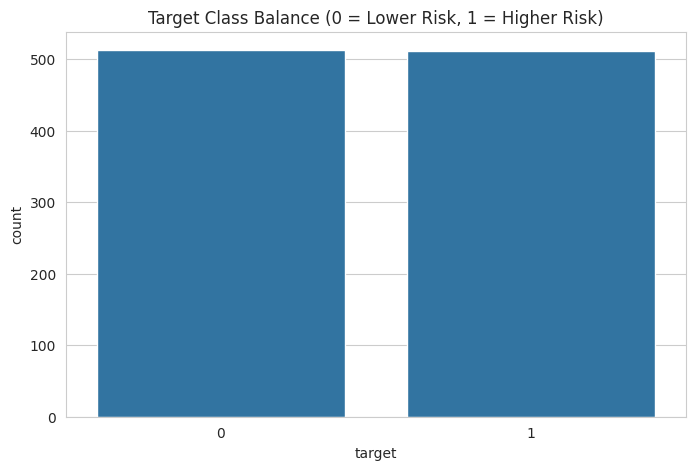

In [8]:
risk_features = ["age", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak"]
direction = {  # +1 = higher is riskier, -1 = lower is riskier
    "age": 1, "trestbps": 1, "chol": 1, "fbs": 1,
    "restecg": 1, "thalach": -1, "exang": 1, "oldpeak": 1
}

z = (df[risk_features] - df[risk_features].mean()) / df[risk_features].std()
for f in risk_features:
    z[f] = z[f] * direction[f]

risk_score = z.sum(axis=1)
df["target"] = (risk_score > risk_score.median()).astype(int)

print(df["target"].value_counts())
sns.countplot(x="target", data=df)
plt.title("Target Class Balance (0 = Lower Risk, 1 = Higher Risk)")
plt.show()


## 3. Train / Test Split

In [9]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (820, 10)  Test size: (205, 10)


## 4. Train a Decision Tree Classifier

In [10]:
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt.fit(X_train, y_train)

train_acc = accuracy_score(y_train, dt.predict(X_train))
test_acc = accuracy_score(y_test, dt.predict(X_test))
print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")
print("\nClassification report (test set):\n", classification_report(y_test, dt.predict(X_test)))


Train accuracy: 1.000
Test accuracy:  0.985

Classification report (test set):
               precision    recall  f1-score   support

           0       1.00      0.97      0.99       103
           1       0.97      1.00      0.99       102

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



### Visualize the Decision Tree

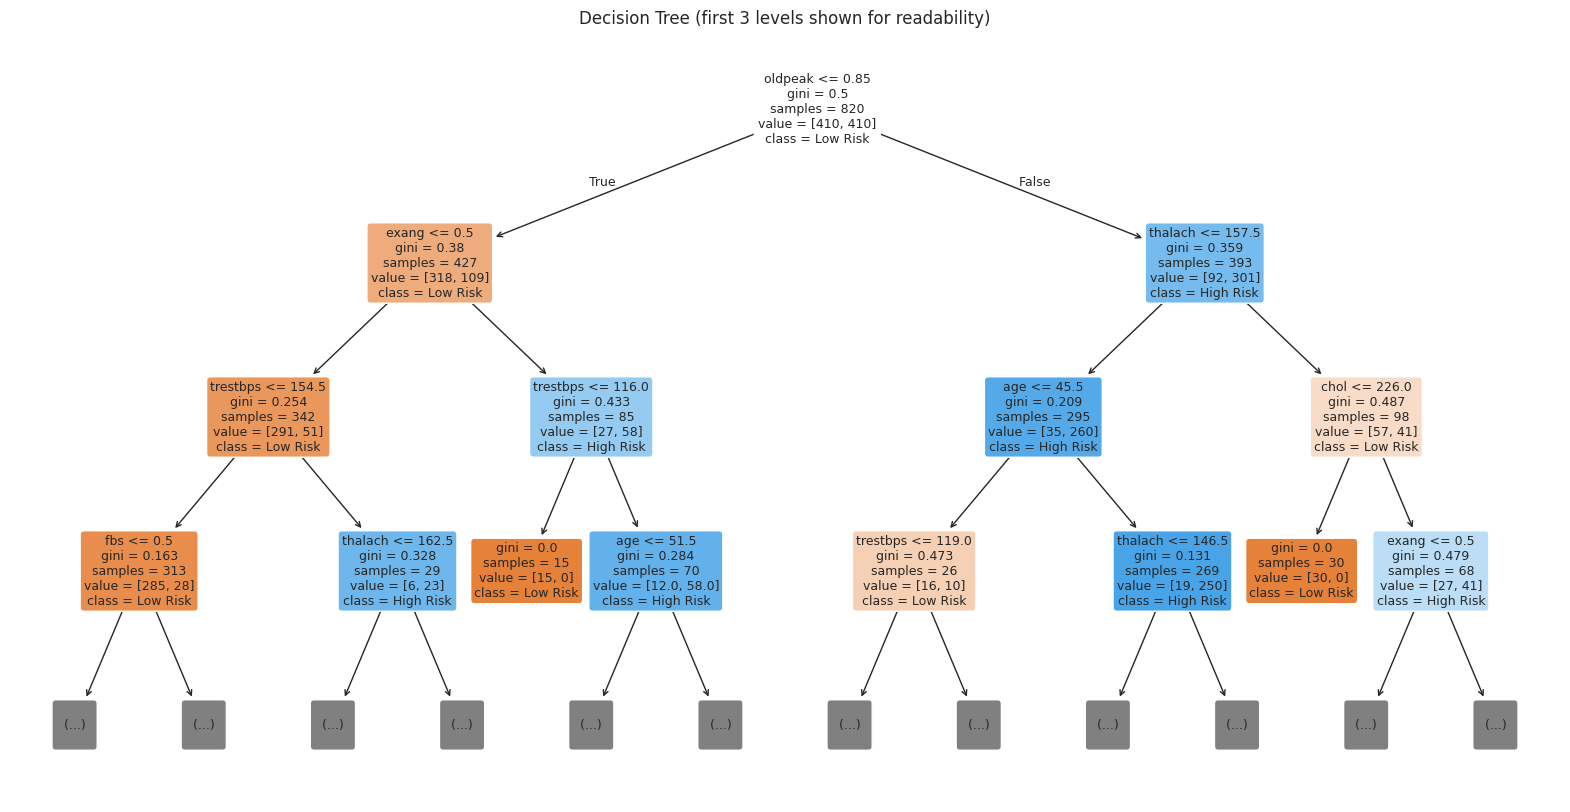

In [11]:
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=X.columns, class_names=["Low Risk", "High Risk"],
          filled=True, rounded=True, max_depth=3, fontsize=9)
plt.title("Decision Tree (first 3 levels shown for readability)")
plt.show()


## 5. Analyze Overfitting — Controlling Tree Depth

A fully grown tree memorizes the training data (high train accuracy, lower
test accuracy = overfitting). We sweep `max_depth` and compare train vs. test
accuracy to find a good balance.


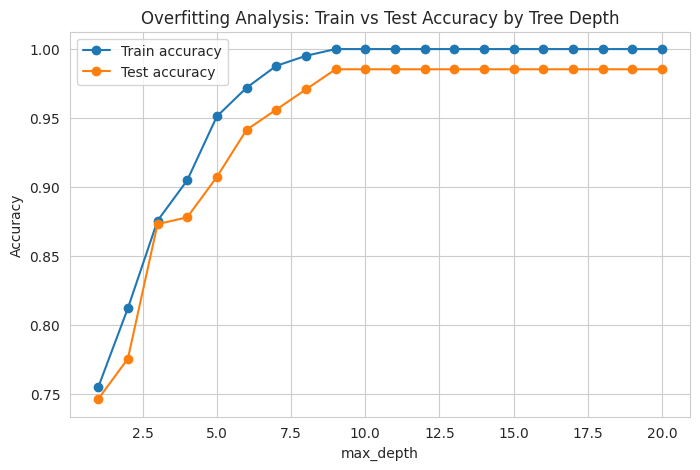

Best max_depth by test accuracy: 9 (test acc = 0.985)


In [12]:
depths = range(1, 21)
train_scores, test_scores = [], []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(depths, train_scores, marker="o", label="Train accuracy")
plt.plot(depths, test_scores, marker="o", label="Test accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Analysis: Train vs Test Accuracy by Tree Depth")
plt.legend()
plt.show()

best_depth = depths[int(np.argmax(test_scores))]
print(f"Best max_depth by test accuracy: {best_depth} (test acc = {max(test_scores):.3f})")


In [13]:
dt_tuned = DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
dt_tuned.fit(X_train, y_train)
print("Tuned Decision Tree test accuracy:", accuracy_score(y_test, dt_tuned.predict(X_test)))


Tuned Decision Tree test accuracy: 0.9853658536585366


## 6. Train a Random Forest and Compare Accuracy

In [14]:
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest train accuracy: {rf_train_acc:.3f}")
print(f"Random Forest test accuracy:  {rf_test_acc:.3f}")

print(f"\nComparison @ test set:")
print(f"  Single Decision Tree (default, unpruned): {test_acc:.3f}")
print(f"  Single Decision Tree (max_depth={best_depth}):        {accuracy_score(y_test, dt_tuned.predict(X_test)):.3f}")
print(f"  Random Forest (200 trees):                 {rf_test_acc:.3f}")


Random Forest train accuracy: 1.000
Random Forest test accuracy:  1.000

Comparison @ test set:
  Single Decision Tree (default, unpruned): 0.985
  Single Decision Tree (max_depth=9):        0.985
  Random Forest (200 trees):                 1.000


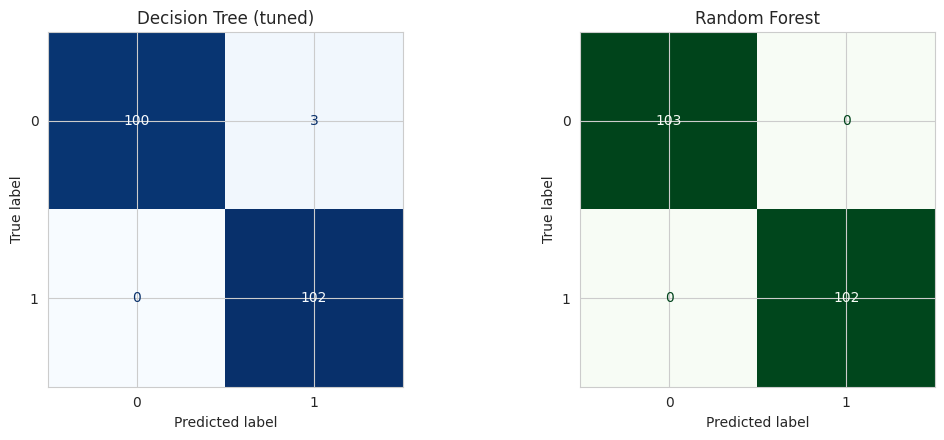

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_estimator(dt_tuned, X_test, y_test, ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Decision Tree (tuned)")
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("Random Forest")
plt.tight_layout()
plt.show()


## 7. Interpret Feature Importances

In [16]:
importances = pd.DataFrame({
    "feature": X.columns,
    "decision_tree": dt_tuned.feature_importances_,
    "random_forest": rf.feature_importances_
}).sort_values("random_forest", ascending=False)

importances


,feature,decision_tree,random_forest
0,age,0.102590,0.195241
7,thalach,0.203746,0.178934
9,oldpeak,0.265033,0.174393
8,exang,0.119186,0.118165
3,trestbps,0.166570,0.109499
4,chol,0.071304,0.101783
5,fbs,0.048024,0.057352
2,cp,0.008838,0.032493
6,restecg,0.005854,0.020957
1,sex,0.008854,0.011182


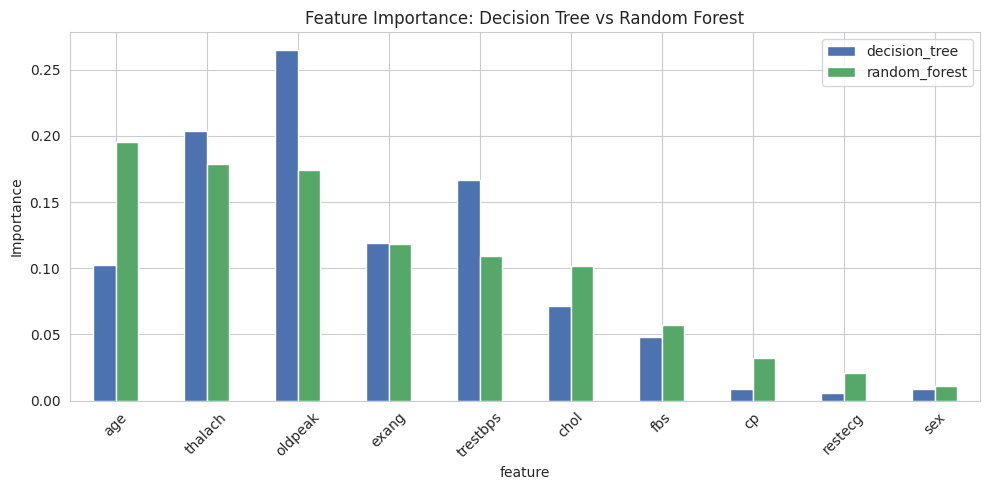

In [17]:
importances.set_index("feature")[["decision_tree", "random_forest"]].plot(
    kind="bar", figsize=(10, 5), color=["#4C72B0", "#55A868"]
)
plt.title("Feature Importance: Decision Tree vs Random Forest")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 8. Evaluate Using Cross-Validation

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dt_cv_scores = cross_val_score(DecisionTreeClassifier(max_depth=best_depth, random_state=RANDOM_STATE), X, y, cv=cv)
rf_cv_scores = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE), X, y, cv=cv)

print("Decision Tree  5-fold CV accuracy: {:.3f} ± {:.3f}".format(dt_cv_scores.mean(), dt_cv_scores.std()))
print("Random Forest  5-fold CV accuracy: {:.3f} ± {:.3f}".format(rf_cv_scores.mean(), rf_cv_scores.std()))


Decision Tree  5-fold CV accuracy: 0.995 ± 0.006
Random Forest  5-fold CV accuracy: 1.000 ± 0.000


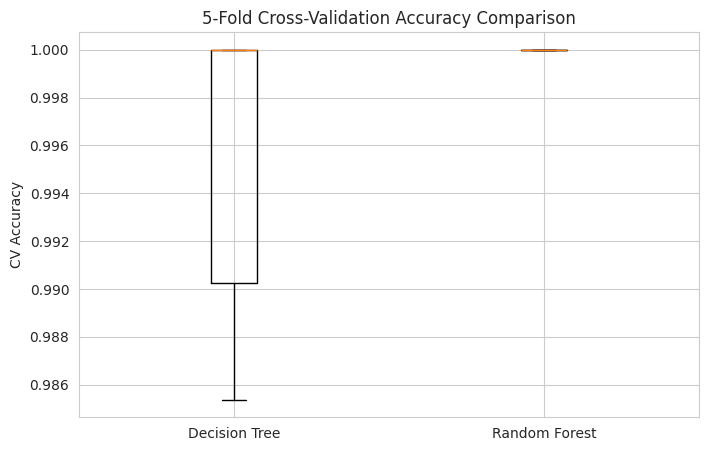

In [19]:
plt.boxplot([dt_cv_scores, rf_cv_scores], tick_labels=["Decision Tree", "Random Forest"])
plt.ylabel("CV Accuracy")
plt.title("5-Fold Cross-Validation Accuracy Comparison")
plt.show()


## 9. Summary

- A single, unpruned Decision Tree tends to **overfit** the training data (near-perfect
  train accuracy but noticeably lower test accuracy).
- Restricting `max_depth` reduces overfitting and improves generalization on the test set.
- The **Random Forest** (an ensemble of many trees trained on bootstrapped samples with
  random feature subsets — *bagging*) achieves comparable or better test accuracy than a
  single tree, with **lower variance** across cross-validation folds.
- The most influential features (see feature importance chart) are consistent with
  clinical knowledge of cardiac risk factors, which is expected since the target itself
  was derived from those same features (see the caveat in Section 2).

See `README.md` for the write-up and interview question answers.
